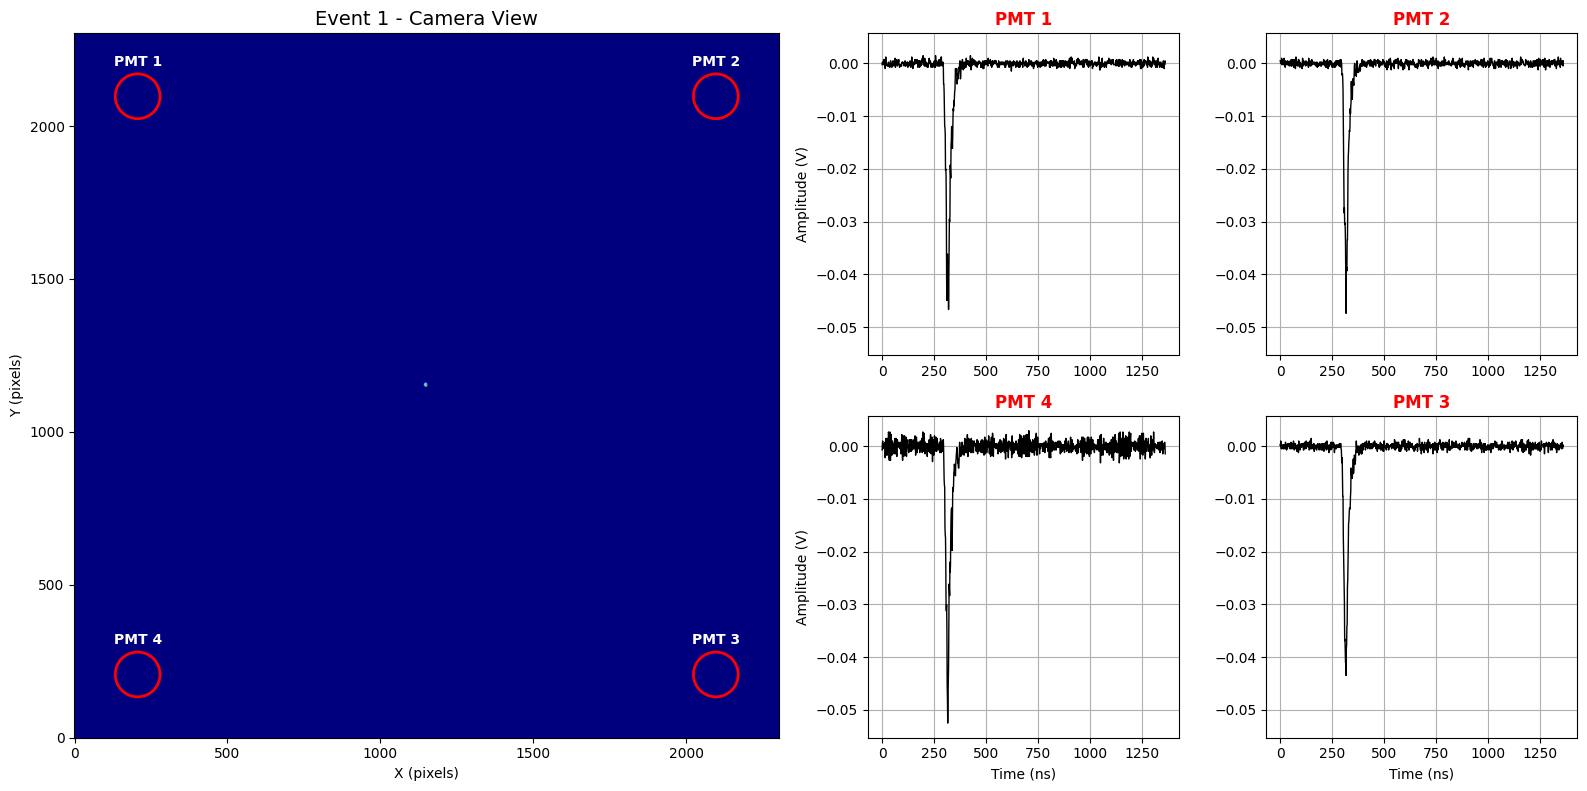

In [9]:
import matplotlib.pyplot as plt
import uproot
import numpy as np

# ==============================================================================
# 1. GEOMETRY AND CONFIGURATION
# ==============================================================================

sim_dim_mm = 346.0  
img_dim_px = 2304   

px_per_mm = img_dim_px / sim_dim_mm
half_sim_dim = sim_dim_mm / 2.0

# PMT Coordinates (Centered Reference Frame 346x346)
pmt_coords = {
    'pmt_1': {'x': -142.0, 'y': -142.0, 'label': 'PMT 1 (Top-L)'},
    'pmt_2': {'x': 142.0,  'y': -142.0, 'label': 'PMT 2 (Top-R)'},
    'pmt_3': {'x': 142.0,  'y': 142.0,  'label': 'PMT 3 (Bot-R)'},
    'pmt_4': {'x': -142.0, 'y': 142.0,  'label': 'PMT 4 (Bot-L)'}
}

# ==============================================================================
# 2. LOAD ROOT FILE
# ==============================================================================

ev_id = 1       
run_id = 1       
energy_kev = 6 

path_root = f'/jupyter-workspace/private/digitization_pmt/digitizationpp/OutputDir/CYGNO_60_40_ER_{energy_kev}_keV/histograms_Run{run_id:05d}.root'

file = uproot.open(path_root, object_cache=None, array_cache=None)

# --------------------------------------------------------------------------
# 2.1 Load Camera Image
# --------------------------------------------------------------------------
img_name = f'pic_run{run_id}_ev{ev_id}'
img = file[img_name].values()

img = np.flipud(img.T)

# --------------------------------------------------------------------------
# 2.2 Load PMT Waveforms
# --------------------------------------------------------------------------
tree = file["event_info"]

arrays = tree.arrays(
    ["wav_fast_pmt1", "wav_fast_pmt2", "wav_fast_pmt3", "wav_fast_pmt4"],
    entry_start=ev_id, 
    entry_stop=ev_id+1,
    library="np"
)

fast_signals = {
    'pmt_1': arrays["wav_fast_pmt1"][0],
    'pmt_2': arrays["wav_fast_pmt2"][0],
    'pmt_3': arrays["wav_fast_pmt3"][0],
    'pmt_4': arrays["wav_fast_pmt4"][0]
}

# --------------------------------------------------------------------------
# 2.3 Time Array Reconstruction
# --------------------------------------------------------------------------
freq_Hz = 750e6
dt_ns = (1.0 / freq_Hz) * 1e9
n_samples = len(fast_signals['pmt_1'])
time_ns = np.arange(n_samples) * dt_ns

# ==============================================================================
# 3. VISUALIZATION
# ==============================================================================

plt.close('all') 
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 4) 

# --------------------------------------------------------------------------
# 3.1 Camera Image Plot
# --------------------------------------------------------------------------
ax_img = fig.add_subplot(gs[:, :2])
im = ax_img.imshow(img, cmap='jet', vmin=0, vmax=np.max(img)*0.8, origin="lower")

ax_img.set_title(f'Event {ev_id} - Camera View', fontsize=14)
ax_img.set_xlabel('X (pixels)')
ax_img.set_ylabel('Y (pixels)')

for pmt, data in pmt_coords.items():
    # Convert from physical centered frame to image pixel coordinates
    # Y axis is inverted due to Matplotlib 'origin=lower' orientation
    x_px = (data['x'] + half_sim_dim) * px_per_mm
    y_px = (half_sim_dim - data['y']) * px_per_mm
    
    # Radius set to 11 mm as defined in the simulation configuration
    pmt_radius_px = 11.0 * px_per_mm
    ax_img.add_patch(plt.Circle((x_px, y_px), radius=pmt_radius_px, color='red', fill=False, lw=2))
    
    ax_img.text(x_px, y_px + 100, pmt.upper().replace('_',' '), color='white', ha='center', fontweight='bold')

# --------------------------------------------------------------------------
# 3.2 Signal Plots 
# --------------------------------------------------------------------------

# --- PMT 1 (Top-Left) ---
ax_p1 = fig.add_subplot(gs[0, 2])
ax_p1.plot(time_ns, fast_signals['pmt_1'], 'k', lw=1)
ax_p1.set_title("PMT 1", color='red', fontweight='bold')
ax_p1.grid(True)
ax_p1.set_ylabel("Amplitude (V)")

# --- PMT 2 (Top-Right) ---
ax_p2 = fig.add_subplot(gs[0, 3], sharey=ax_p1) 
ax_p2.plot(time_ns, fast_signals['pmt_2'], 'k', lw=1)
ax_p2.set_title("PMT 2", color='red', fontweight='bold')
ax_p2.grid(True)

# --- PMT 4 (Bottom-Left) ---
ax_p4 = fig.add_subplot(gs[1, 2], sharex=ax_p1, sharey=ax_p1)
ax_p4.plot(time_ns, fast_signals['pmt_4'], 'k', lw=1)
ax_p4.set_title("PMT 4", color='red', fontweight='bold')
ax_p4.grid(True)
ax_p4.set_xlabel("Time (ns)")
ax_p4.set_ylabel("Amplitude (V)")

# --- PMT 3 (Bottom-Right) ---
ax_p3 = fig.add_subplot(gs[1, 3], sharex=ax_p2, sharey=ax_p1)
ax_p3.plot(time_ns, fast_signals['pmt_3'], 'k', lw=1)
ax_p3.set_title("PMT 3", color='red', fontweight='bold')
ax_p3.grid(True)
ax_p3.set_xlabel("Time (ns)")

plt.tight_layout()
plt.show()